In [1]:
import warnings

warnings.filterwarnings("ignore")

import sys
import os


import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#plt.style.use("ggplot")
sns.set_theme(style="ticks")
sns.set_context("paper")
sns.color_palette("husl", 8)
#plt.style.use('grayscale')
# Seaborn のスタイルとコンテキストを設定

import re
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
from sklearn.linear_model import (
    LassoCV,
    Lasso,
)


sys.path.append(os.path.abspath("../"))
from dmldid.simdata_genrater import generate_simdata_ro, convert_rcs

# Verification with simulation data
## simulation data
-  repeated cross-section data
- true ATT := 3
- dim(X) := 100
- N = 500

In [2]:
df_rcs =  convert_rcs(
    generate_simdata_ro(true_att=3, _n=1000, _dim=100, base_seed=1, xd_unobserved=True)
)

df_rcs.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x93,x94,x95,x96,x97,x98,x99,D,Y,T
0,1.657684,-0.589531,-0.511503,-1.059633,0.876520,-2.301539,1.744812,-0.761207,0.319039,-0.249370,...,-0.638730,0.423494,0.077340,-0.343854,0.043597,-0.620001,0.698032,1,-2.608892,0
1,-0.571090,1.141867,0.341511,0.543994,-1.136232,0.169382,0.740556,-0.953701,-0.266219,0.032615,...,1.111057,0.659050,-1.627438,0.602319,0.420282,0.810952,1.044442,0,-3.148893,1
2,-0.186920,0.966645,-0.455326,2.040461,-1.260632,-1.760689,-1.650721,-0.890556,-1.119115,1.956079,...,-0.680678,-0.084508,-0.297362,0.417302,0.784771,-0.955425,0.585910,1,-3.894205,0
3,1.599364,-1.782103,-1.063381,-1.067145,-0.434571,1.622849,0.013353,-0.694694,0.621804,-0.599805,...,0.477610,-1.021886,0.794528,-1.873161,0.920615,-0.035368,2.110605,1,-4.406583,0
4,-1.214688,0.137611,0.413155,1.269638,-0.392241,0.086464,-2.142467,-0.830169,0.451616,1.104174,...,0.451946,-1.579156,-0.828628,0.528880,-2.237087,-1.107713,-0.017718,0,-5.072539,0


In [3]:
y_col = "Y"
d_col = "D"
t_col = "T"
X_cols = [col for col in df_rcs.columns if "x" in col]

## Chang(2022)'s l2k model

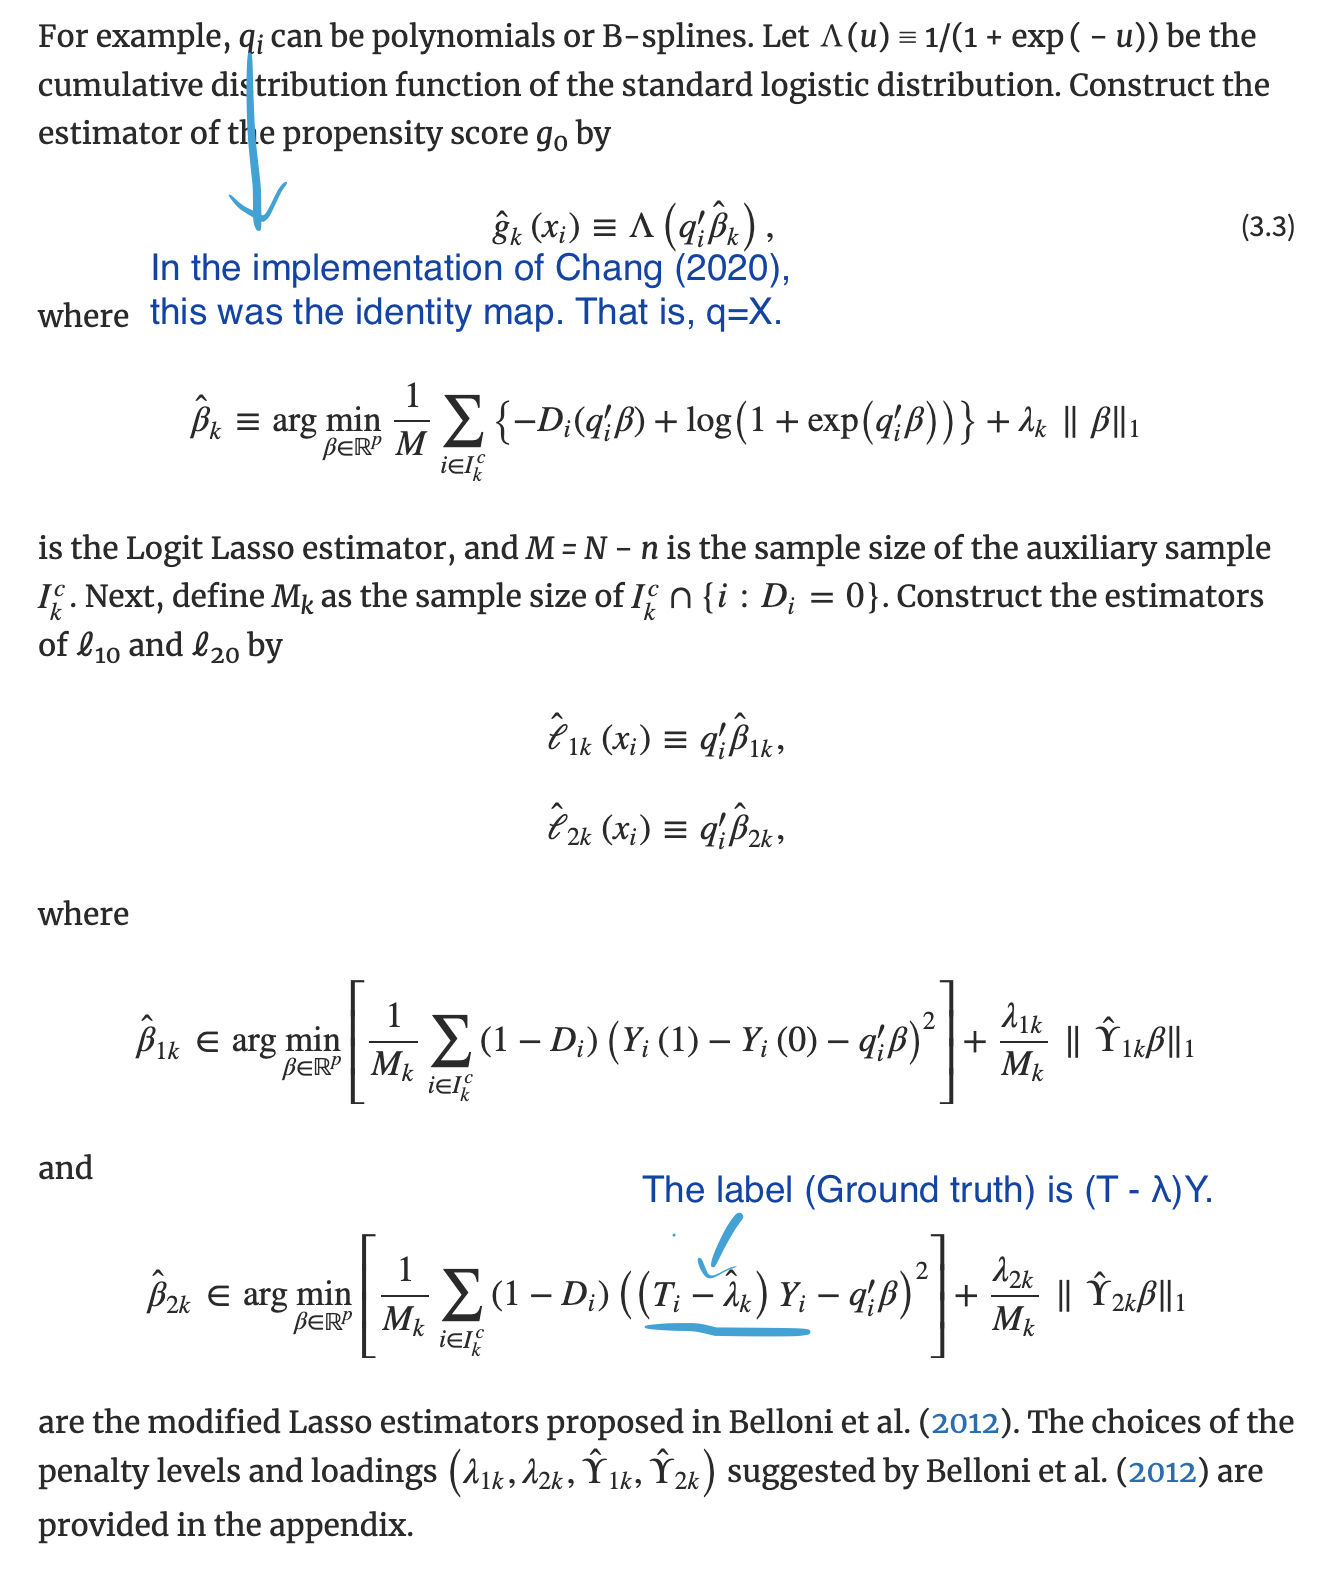

## [X -> l2k label] regression is almost nonsense
### simple example

In [4]:
hat_lambda = df_rcs["T"].mean()

control_df = df_rcs.query("D < 1")
control_df["l2k_y"] = (control_df["T"] - hat_lambda) * control_df["Y"]

In [5]:
control_df[X_cols + ["Y"]].corr()[["Y"]]

,Y
x0,0.436142
x1,0.347650
x2,0.307597
x3,0.322130
x4,0.280798
...,...
x96,0.040941
x97,0.002225
x98,0.064417
x99,0.049610


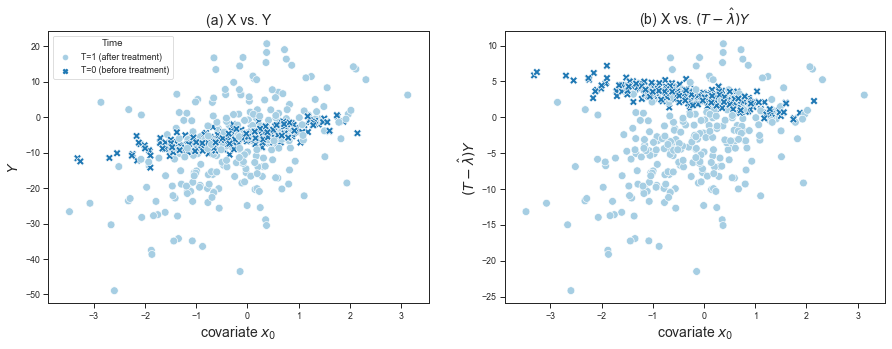

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

sns.scatterplot(
    x="x0",
    y="Y",
    hue="Time",
    style="Time",
    data=control_df.assign(
        Time=np.where(
            control_df["T"] > 0, "T=1 (after treatment)", "T=0 (before treatment)"
        )
    ),
    ax=axs[0],
    legend="full",
    palette="Paired",
    s=60,
)
axs[0].set_title("(a) X vs. Y", fontsize=14)
axs[0].set_ylabel("$Y$", fontsize=14)
axs[0].set_xlabel("covariate $x_0$", fontsize=14)


sns.scatterplot(
    x="x0",
    y="l2k_y",
    hue="Time",
    style="Time",
    data=control_df.assign(
        Time=np.where(
            control_df["T"] > 0, "T=1 (after treatment)", "T=0 (before treatment)"
        )
    ),
    ax=axs[1],
    legend=False,
    palette="Paired",
    s=60,
)
axs[1].set_title("(b) X vs. $(T - \hat{\lambda })Y$", fontsize=14)
axs[1].set_xlabel("covariate $x_0$", fontsize=14)
axs[1].set_ylabel("$(T - \hat{\lambda })Y$", fontsize=14)
fig.savefig("../fig/covariate_to_label.png", dpi=600, bbox_inches="tight")
fig.show()

## (1) simple regression result


In [7]:
x_train, x_test, y_train, y_test, l2k_y_train, l2k_y_test = train_test_split(
    control_df[X_cols + [t_col]],
    control_df[y_col],
    control_df["l2k_y"],
    test_size=0.3,
    random_state=0,
)


y_model = LassoCV(cv=5, random_state=0)
l2k_model_withoutT = LassoCV(cv=5, random_state=0)
l2k_model = LassoCV(cv=5, random_state=0)

y_model.fit(x_train, y_train)
l2k_model_withoutT.fit(x_train.iloc[:, :-1], l2k_y_train)
l2k_model.fit(x_train, l2k_y_train)

y_pred = y_model.predict(x_test)
y_mse = mean_squared_error(y_test, y_pred)

l2k_y_pred_withoutT = l2k_model_withoutT.predict(x_test.iloc[:, :-1])
l2k_mse_withoutT = mean_squared_error(l2k_y_test, l2k_y_pred_withoutT)

l2k_y_pred = l2k_model.predict(x_test)
l2k_mse = mean_squared_error(l2k_y_test, l2k_y_pred)

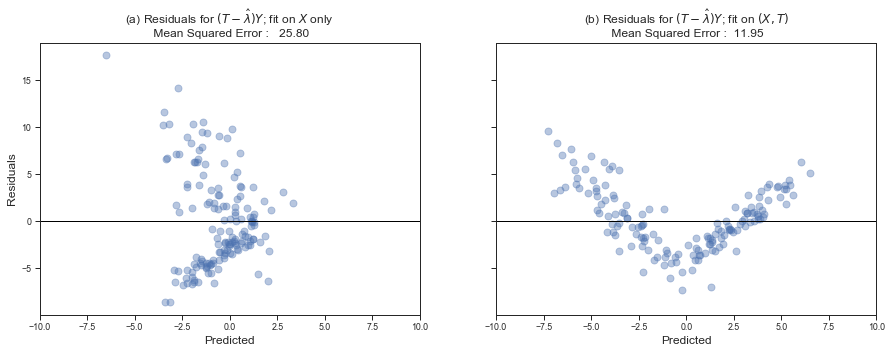

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

axs[0].scatter(
    l2k_y_pred_withoutT,
    l2k_y_pred_withoutT - l2k_y_test,
    marker="o",
    s=50,
    alpha=0.4,
    # color="black",
    label="l2k regression",
)
axs[0].set_xlabel("Predicted",fontsize=12)
axs[0].set_ylabel("Residuals",fontsize=12)
axs[0].hlines(y=0, xmin=y_pred.min(), xmax=10, lw=1, color="black")
axs[0].set_xlim(-10,10)
axs[0].set_title(
    "(a) Residuals for $(T-\hat{\lambda})Y$; fit on $X$ only"
    + f"\n Mean Squared Error :  {l2k_mse_withoutT : .2f}",
    fontsize=12,
)

axs[1].scatter(
    l2k_y_pred,
    l2k_y_pred - l2k_y_test,
    marker="o",
    s=50,
    alpha=0.4,
    # color="black",
    label="l2k regression",
)

axs[1].set_xlabel("Predicted",fontsize=12)
axs[1].set_xlim(-10,10)
axs[1].hlines(y=0, xmin=l2k_y_pred.min(), xmax=10, lw=1, color="black")
axs[1].set_title(
    "(b) Residuals for $(T-\hat{\lambda})Y$; fit on $(X,T)$"
    + f"\n Mean Squared Error : {l2k_mse : .2f}",
    fontsize=12,
)
fig.savefig("../fig/original_l2kmodel_wrong.png", dpi=600, bbox_inches="tight")
plt.show()

## (2) separate model on T

In [9]:
control_df_t1 = control_df.query("T>0")
control_df_t0 = control_df.query("T<1")

x_train_t1, x_test_t1, y_train_t1, y_test_t1 = train_test_split(
    control_df_t1[X_cols],
    control_df_t1[y_col],
    test_size=0.3,
    random_state=0,
)

x_train_t0, x_test_t0, y_train_t0, y_test_t0 = train_test_split(
    control_df_t0[X_cols],
    control_df_t0[y_col],
    test_size=0.3,
    random_state=0,
)


y_model_t1 = LassoCV(cv=5, random_state=0)
y_model_t0 = LassoCV(cv=5, random_state=0)

y_model_t1.fit(x_train_t1, y_train_t1)
y_model_t0.fit(x_train_t0, y_train_t0)

y_pred_t1 = y_model_t1.predict(x_test_t1)
y_mse_t1 = mean_squared_error(y_test_t1, y_pred_t1)

y_pred_t0 = y_model_t0.predict(x_test_t0)
y_mse_t0 = mean_squared_error(y_test_t0, y_pred_t0)

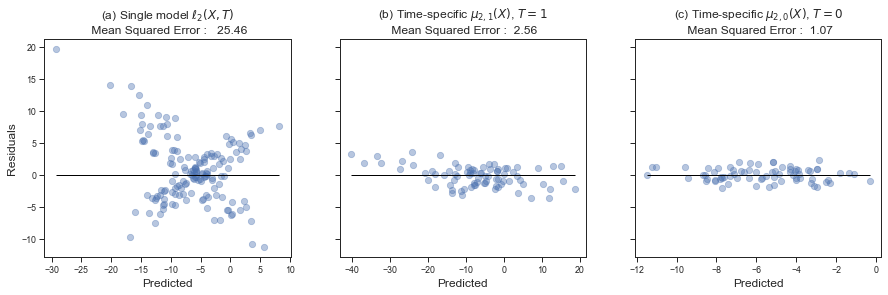

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

axs[0].scatter(
    y_pred,
    y_pred - y_test,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="l2k regression",
)
axs[0].set_ylabel("Residuals", fontsize=12)
axs[0].set_xlabel("Predicted", fontsize=12)
axs[0].hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), lw=1, color="black")
axs[0].set_title(f"(a) Single model $\ell_2(X,T)$\n Mean Squared Error :  {y_mse : .2f}", fontsize=12)

axs[1].scatter(
    y_pred_t1,
    y_pred_t1 - y_test_t1,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="y regression_t1",
)
axs[1].set_xlabel("Predicted", fontsize=12)

axs[1].hlines(y=0, xmin=y_pred_t1.min(), xmax=y_pred_t1.max(), lw=1, color="black")
axs[1].set_title(f"(b) Time-specific $\mu_{{2,1}}(X)$, $T=1$\n Mean Squared Error : {y_mse_t1 : .2f}", fontsize=12)

axs[2].scatter(
    y_pred_t0,
    y_pred_t0 - y_test_t0,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="y regression_t0",
)
axs[2].set_xlabel("Predicted", fontsize=12)
axs[2].hlines(y=0, xmin=y_pred_t0.min(), xmax=y_pred_t0.max(), lw=1, color="black")
axs[2].set_title(f"(c) Time-specific $\mu_{{2,0}}(X)$, $T=0$\n Mean Squared Error : {y_mse_t0 : .2f}", fontsize=12)


fig.savefig("../fig/our_suolution.png", dpi=600, bbox_inches="tight")
plt.show()

## (3) nonlinear model

In [11]:
df_rcs = convert_rcs(
    generate_simdata_ro(true_att=3, _n=1000, _dim=100, base_seed=1, xd_unobserved=True)
)

hat_lambda = df_rcs["T"].mean()

control_df = df_rcs.query("D < 1")
control_df["l2k_y"] = (control_df["T"] - hat_lambda) * control_df["Y"]


x_train, x_test, y_train, y_test, l2k_y_train, l2k_y_test = train_test_split(
    control_df[X_cols + [t_col]],
    control_df[y_col],
    control_df["l2k_y"],
    test_size=0.3,
    random_state=0,
)

control_df_t1 = control_df.query("T>0")
control_df_t0 = control_df.query("T<1")

x_train_t1, x_test_t1, y_train_t1, y_test_t1 = train_test_split(
    control_df_t1[X_cols],
    control_df_t1[y_col],
    test_size=0.3,
    random_state=0,
)

x_train_t0, x_test_t0, y_train_t0, y_test_t0 = train_test_split(
    control_df_t0[X_cols],
    control_df_t0[y_col],
    test_size=0.3,
    random_state=0,
)

In [12]:
y_model = LGBMRegressor(random_state=0)
l2k_model = LGBMRegressor(random_state=0)
y_model_t1 = LGBMRegressor(random_state=0)
y_model_t0 = LGBMRegressor(random_state=0)

y_model.fit(x_train, y_train)
l2k_model.fit(x_train, l2k_y_train)

y_pred = y_model.predict(x_test)
y_mse = mean_squared_error(y_test, y_pred)

l2k_y_pred = l2k_model.predict(x_test)
l2k_mse = mean_squared_error(l2k_y_test, l2k_y_pred)

y_model_t1.fit(x_train_t1, y_train_t1)
y_model_t0.fit(x_train_t0, y_train_t0)

y_pred_t1 = y_model_t1.predict(x_test_t1)
y_mse_t1 = mean_squared_error(y_test_t1, y_pred_t1)

y_pred_t0 = y_model_t0.predict(x_test_t0)
y_mse_t0 = mean_squared_error(y_test_t0, y_pred_t0)

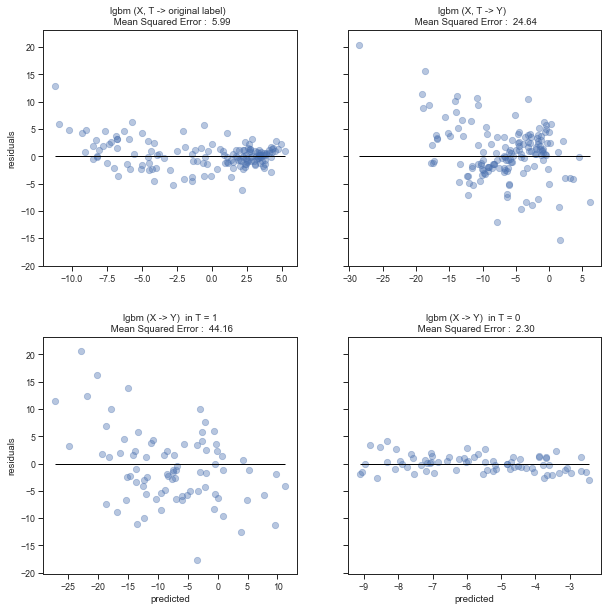

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
fig.subplots_adjust(hspace=0.3)
axs = axs.ravel()
axs[0].scatter(
    l2k_y_pred,
    l2k_y_pred - l2k_y_test,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="l2k regression",
)

# axs[0].set_xlabel("predicted")
axs[0].set_ylabel("residuals")
axs[0].hlines(y=0, xmin=l2k_y_pred.min(), xmax=l2k_y_pred.max(), lw=1, color="black")
axs[0].set_title(f"lgbm (X, T -> original label)  \n Mean Squared Error : {l2k_mse : .2f}")

axs[1].scatter(
    y_pred,
    y_pred - y_test,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="y regression",
)
#axs[1].set_xlabel("predicted")
axs[1].hlines(y=0, xmin=y_pred.min(), xmax=y_pred.max(), lw=1, color="black")
axs[1].set_title(f"lgbm (X, T -> Y)  \n Mean Squared Error : {y_mse : .2f}")



axs[2].scatter(
    y_pred_t1,
    y_pred_t1 - y_test_t1,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="y regression_t1",
)
axs[2].set_xlabel("predicted")
axs[2].set_ylabel("residuals")
axs[2].hlines(y=0, xmin=y_pred_t1.min(), xmax=y_pred_t1.max(), lw=1, color="black")
axs[2].set_title(f"lgbm (X -> Y)  in T = 1\n Mean Squared Error : {y_mse_t1 : .2f}")

axs[3].scatter(
    y_pred_t0,
    y_pred_t0 - y_test_t0,
    marker="o",
    s=40,
    alpha=0.4,
    # color="black",
    label="y regression_t0",
)
axs[3].set_xlabel("predicted")
axs[3].hlines(y=0, xmin=y_pred_t0.min(), xmax=y_pred_t0.max(), lw=1, color="black")
axs[3].set_title(f"lgbm (X -> Y)  in T = 0 \n Mean Squared Error : {y_mse_t0 : .2f}")


#fig.savefig("../fig/lgbm_suolution.png")
plt.show()

In [14]:
print("Done")

Done
